# Week 13 - Bivariate Analysis 2 - Statistics

# 

# 1. Lesson

We are going to consider some statistical tests that you can apply to your data.

### T-tests

You can use a t-test to discern whether the means of two sets of numbers might be the same.  The t-test is useful for data that are normally distributed.  The data should also have approximately equal variances.  Of course you can run a t-test for data that don't fit these criteria, but the less well it fits, the more likely that the t-test will give the wrong result.

First, here is a one-sample t-test to see if you have made a correct guess about the underlying mean:

In [1]:
from scipy import stats
import numpy as np
np.random.seed(0)
arr1 = np.random.normal(loc = 0, size = 1000)
t_stat, p_value = stats.ttest_1samp(arr1, 0)
# The array might have a mean of 0; p > 0.05.  In fact, it does have a mean of 0.
print(p_value)

0.14759031545459367


In [2]:
# The array probably does not have a mean of 0.1; p < 0.05.  In fact, it doesn't.
t_stat, p_value = stats.ttest_1samp(arr1, 0.1)
print(p_value)

3.7389682463533554e-06


In [3]:
arr2 = np.random.normal(loc = 0, size = 10)
t_stat, p_value = stats.ttest_1samp(arr2, 0.1)
# This array might have a mean of 0.1; p > 0.05.  In fact, it doesn't - but since there are only ten samples, we can't tell that
print(p_value)

0.8283790364046455


In [4]:
arr3 = np.random.normal(loc = 0.1, size = 1000)
t_stat, p_value = stats.ttest_ind(arr1, arr3)
# The two arrays probably have different means; p < 0.05.  In fact, they do have different means; 0 and 0.1
print(p_value)

0.00045250399702813924


### Mann-Whitney U-test

This test is used to determine whether two sets of numbers might come from the same distribution - but without making any assumptions about the data being normally distributed.

In [5]:
u_value, p_value = stats.mannwhitneyu(arr1, arr3)
# The two arrays probably come from different distributions.  In fact, they do; one comes from mean = 0, one mean = 1.
print(p_value)

0.0006158714688322862


In [6]:
np.random.seed(0)
arr4 = np.concatenate([np.zeros(10) + 0.01, np.array([1])])
arr5 = np.concatenate([np.zeros(10) - 0.01, np.array([-1])])
t_stat, p_value = stats.ttest_ind(arr4, arr5)
# Here is an example where the t-test fails due to the non-normality of the data.  The data do come from different 
# distributions with different means, but the t-test fails to detect it.
print(p_value)

0.1317884015467006


In [7]:
u_value, p_value = stats.mannwhitneyu(arr4, arr5)
# The two arrays probably come from different distributions.  In fact, they do; see above.
# It is unusual for the t-test to fail due to non-normality but the Mann-Whitney U-test to succeed, but it can happen as in this case.
print(p_value)

1.2550539978736685e-05


### ANOVA: categorical data plotted vs. continous data

ANOVA is a t-test generalized to more than two groups

In [8]:
np.random.seed(0)
arr6 = np.random.normal(loc = 0, size = 1000)
arr7 = np.random.normal(loc = 0.1, size = 1000)
arr8 = np.random.normal(loc = 0.2, size = 1000)
result = stats.f_oneway(arr1, arr3, arr6)
# The three arrays probably have different means; p < 0.05.  In fact, as you can see, they do have different means.
print(result.pvalue)

0.0002860198265887807


### Chi-square: categorical data plotted vs. categorical data

Chi-square will test for statistical independence between counts for two categorical features.  To do this, it requires a matrix of numbers: one feature corresponds to the row and one to the column.  The numbers must be counts.  Thus, if the category for the column is weather (cloudy or sunny) and the category for the row is temperature (low, medium, or high), then the count of days in the month at that temperature and weather would be a good variable for chi-square.

In [9]:
arr9 = np.array([[10, 0], [5, 5], [0, 10]])
result = stats.chi2_contingency(arr9)
# Different rows are very different.  Each row is _not_ a fixed multiple of each other, so the variables are not independent.
# Thus, the chi-squared test shows that the data are not independent.  
# In the next example, we will elaborate on what kind of difference is involved
print(result.pvalue)

4.539992976248486e-05


The specific goal of the chi-squared contingency table test is to find out whether the table possesses statistical independence - which is to say, it asks whether each number can be written as a product of two other numbers: one for its row and one for its column.  For example, suppose two stores, A and B, sell two kinds of apples, red and green.  If the number of apples sold is independent, it would mean that we can multiply to get the number sold.  That is, the fraction of the apples that are red and sold at store A would approximately equal the fraction red multiplied by the fraction sold at store A.

In [10]:
A_B_values = np.array([0.4, 0.6])
red_green_values = np.array([0.7, 0.3])
outer_product = 50 * np.outer(A_B_values, red_green_values)
print(outer_product)

[[14.  6.]
 [21.  9.]]


The chi-squared test returns a null result due to the complete independence of the values.  (p > 0.05).  Each row is precisely a fixed multiple of the other.  As above, a low p-value means dependence and a high p-value means independence.

In [11]:
result = stats.chi2_contingency(outer_product)
print(result.pvalue)

1.0


In [12]:
arr9 = np.array([[10, 0], [9, 1], [8, 2]])
result = stats.chi2_contingency(arr9)
# Here, the first columns (10, 9, 8) is quite different in its ratios compared with the second (0, 1, 2)
# However, because the second column has low counts, it is conceivable that these ratios could not be the true ratios.
# This means that perhaps the variables are independent after all, leading to a relatively high p-value - we cannot say for
# sure that the data are not independent.  We'd need more data to say that.
print(result.pvalue)

0.3291929878079054


In [13]:
result = stats.chi2_contingency(arr9 * 3)
# If we have a lot more data, even with the exact same ratios between the rows, we become more certain that the data are not independent
print(arr9 * 3)
print(result.pvalue)

[[30  0]
 [27  3]
 [24  6]]
0.035673993347252395


# 2. Weekly graph question

Which of the following graph color schemes would you choose, and why?

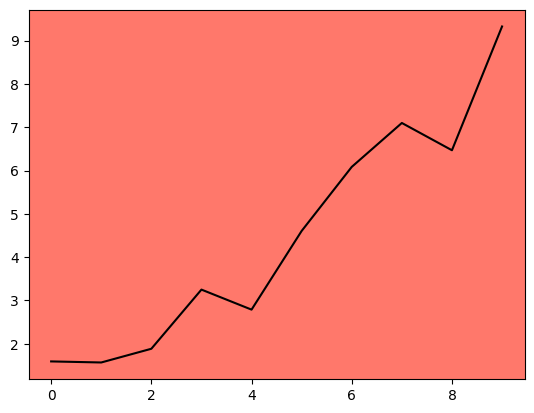

In [14]:
import matplotlib.pyplot as plt
arr10 = np.arange(10)
arr11 = np.random.normal(size = 10) + np.arange(10)
fig = plt.plot(arr10, arr11, c = "black")
ax = plt.gca()
ax.set_facecolor((1.0, 0.47, 0.42))

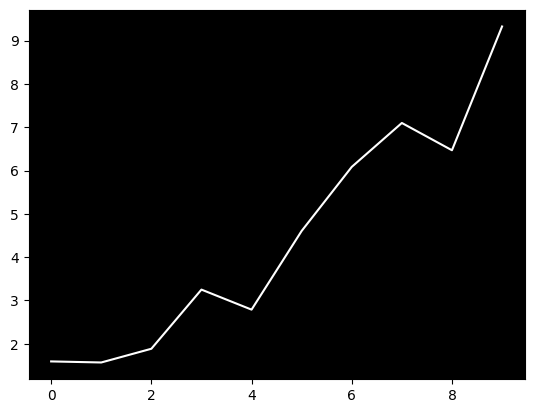

In [15]:
fig = plt.plot(arr10, arr11, c = "white")
ax = plt.gca()
ax.set_facecolor((0, 0, 0))

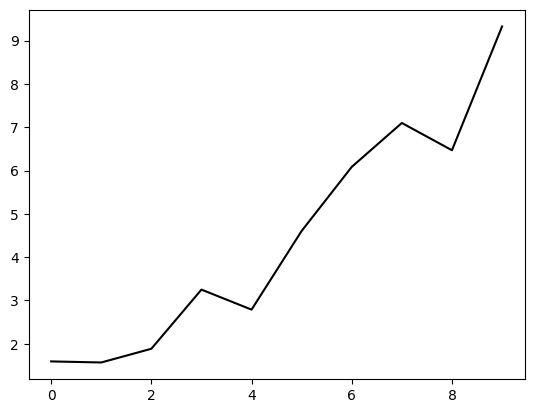

In [16]:
fig = plt.plot(arr10, arr11, c = "black")
ax = plt.gca()
ax.set_facecolor((1, 1, 1))

**Maksim Haurylik**
I would choose the third color scheme (black line on a white background): the contrast is clear, not overwhelming, avoids distractions. 

The first option (red background) is too intense and makes it difficult to focus on the data itself. The second (white line on black) has strong contrast but can hurt the eyes over time.

# 3. Homework

* Create a dataset showing flowers that have been fertilized with two brands of fertilizer.  The data show the heights of the flowers.  One fertilizer is better than the other, leading to taller flowers - but only slightly taller.
* The flowers have some height distribution that is _not_ normal.
* Use a t-test and a Mann-Whitney U test to determine whether the flowers have the same height.  (In this case, try the t-test even though the distribution it not normal.  However, that is not always a good idea!)
* Actually, create two datasets: one where the t-test works (and detects the slight height difference) and one where the t-test fails.
* Draw a box and whisker plot or histogram showing the distribution of the flower heights in each case.  Can you see the difference?
* Next, create a dataset showing five different brands of fertilizer, leading to five somewhat different height distributions.  Use an ANOVA test to detect the height differences.  Does the ANOVA test work?
* Finally, create a dataset showing the heights of four different flower types for each of the five brand of fertilizers (one height for each pair, so 4 x 5 = 20 heights).  Use a chi squared test to check whether the five different fertilizers lead to different flower heights.

Case 1 dataset (first 10 rows):
   Fertilizer_A  Fertilizer_B
0     58.820262     49.154091
1     52.000786     49.803104
2     54.893690     56.498298
3     61.204466     54.276319
4     59.337790     54.200658
5     45.113611     42.915220
6     54.750442     50.878369
7     49.243214     47.309845
8     49.483906     52.399623
9     52.052993     50.509248

T-test p-value: 0.9913027374636167
Mann-Whitney p-value: 0.8786642182938036


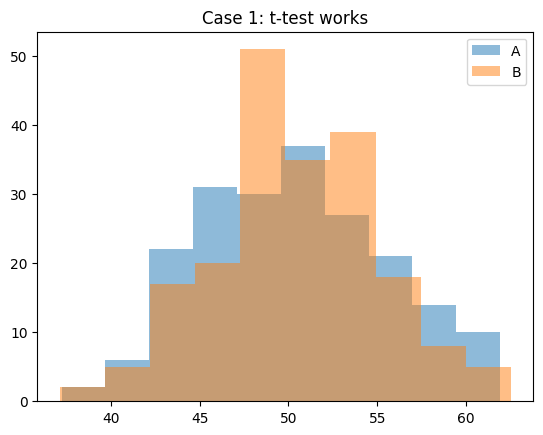

In [28]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(0)

fert_A = np.random.normal(loc=50, scale=5, size=200)
fert_B = np.random.normal(loc=51, scale=5, size=200)

df_case1 = pd.DataFrame({
    "Fertilizer_A": fert_A,
    "Fertilizer_B": fert_B
})

print("Case 1 dataset (first 10 rows):")
print(df_case1.head(10))

# Tests:
t_stat, p_val_t = stats.ttest_ind(fert_A, fert_B)
u_stat, p_val_u = stats.mannwhitneyu(fert_A, fert_B)

print("\nT-test p-value:", p_val_t)
print("Mann-Whitney p-value:", p_val_u)

plt.hist(fert_A, alpha=0.5, label="A")
plt.hist(fert_B, alpha=0.5, label="B")
plt.legend()
plt.title("Case 1: t-test works")
plt.show()

Case 2 dataset (first 10 rows):
   Fertilizer_A  Fertilizer_B
0     48.802692     47.899141
1     47.768206     51.834638
2     51.533326     49.111263
3     50.712586     51.476206
4     46.462923     48.188074
5     50.710964     49.819885
6     51.629040     50.779021
7     50.117851     47.678600
8     49.629893     51.230296
9     48.384703     50.241705

T-test p-value: 0.0031183871060074674
Mann-Whitney p-value: 0.0194124953657057


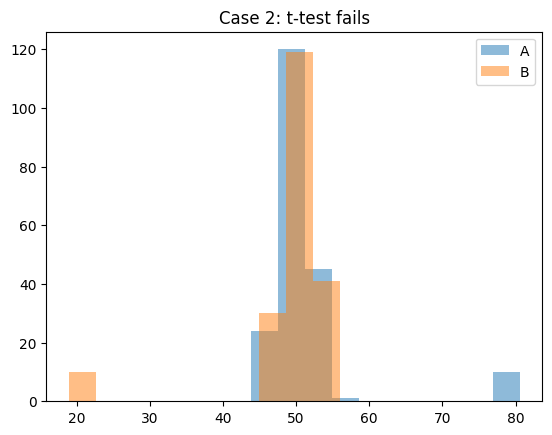

In [29]:
# Non-normal distributions:
fert_A2 = np.concatenate([
    np.random.normal(50, 2, 190),
    np.random.normal(80, 1, 10)
])

fert_B2 = np.concatenate([
    np.random.normal(51, 2, 190),
    np.random.normal(20, 1, 10)
])

df_case2 = pd.DataFrame({
    "Fertilizer_A": fert_A2,
    "Fertilizer_B": fert_B2
})

print("Case 2 dataset (first 10 rows):")
print(df_case2.head(10))

# Tests:
t_stat2, p_val_t2 = stats.ttest_ind(fert_A2, fert_B2)
u_stat2, p_val_u2 = stats.mannwhitneyu(fert_A2, fert_B2)

print("\nT-test p-value:", p_val_t2)
print("Mann-Whitney p-value:", p_val_u2)

plt.hist(fert_A2, alpha=0.5, label="A")
plt.hist(fert_B2, alpha=0.5, label="B")
plt.legend()
plt.title("Case 2: t-test fails")
plt.show()

Dataset (first 5 rows):
       Fert1      Fert2      Fert3      Fert4      Fert5
0  58.820262  50.154091  51.006730  48.247853  65.055860
1  52.000786  50.803104  48.420515  58.086594  61.929019
2  54.893690  57.498298  57.833316  51.278158  57.712652
3  61.204466  55.276319  55.781464  57.190516  56.043915
4  59.337790  55.200658  45.157308  48.970185  62.704588

Group means:
Fert1    50.354552
Fert2    51.359928
Fert3    53.461262
Fert4    55.353628
Fert5    58.339213
dtype: float64

ANOVA results:
F-statistic: 84.41924831707115
p-value: 9.339981720824832e-62


/tmp/ipykernel_2957/2915593219.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fert1, fert2, fert3, fert4, fert5],


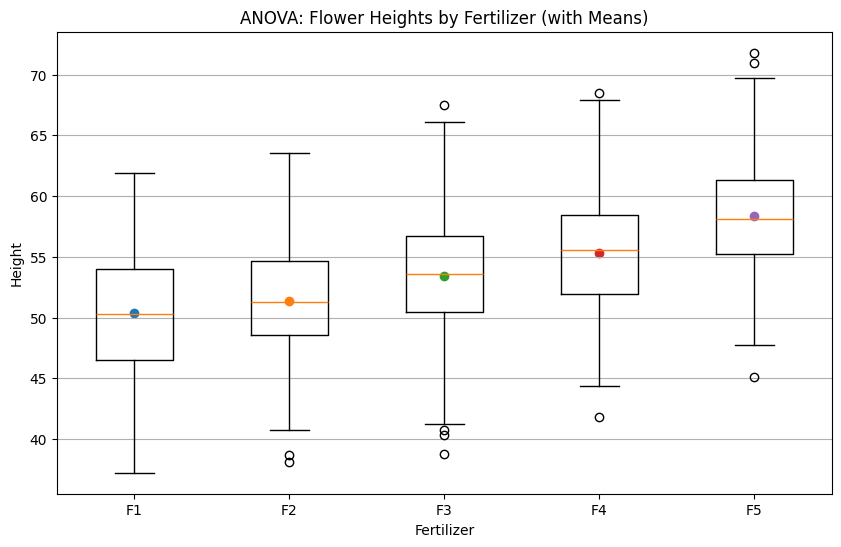

In [33]:
# ANOVA:
np.random.seed(0)

# Create (5 fertilizers with different means)
fert1 = np.random.normal(50, 5, 200)
fert2 = np.random.normal(52, 5, 200)
fert3 = np.random.normal(54, 5, 200)
fert4 = np.random.normal(56, 5, 200)
fert5 = np.random.normal(58, 5, 200)

df = pd.DataFrame({
    "Fert1": fert1,
    "Fert2": fert2,
    "Fert3": fert3,
    "Fert4": fert4,
    "Fert5": fert5
})

print("Dataset (first 5 rows):")
print(df.head())

means = df.mean()
print("\nGroup means:")
print(means)

# ANOVA test
f_stat, p_value = stats.f_oneway(fert1, fert2, fert3, fert4, fert5)
print("\nANOVA results:")
print("F-statistic:", f_stat)
print("p-value:", p_value)

plt.figure(figsize=(10, 6))
plt.boxplot([fert1, fert2, fert3, fert4, fert5],
            labels=["F1", "F2", "F3", "F4", "F5"])

for i, mean in enumerate(means):
    plt.scatter(i+1, mean, marker='o')

plt.title("ANOVA: Flower Heights by Fertilizer (with Means)")
plt.ylabel("Height")
plt.xlabel("Fertilizer")

plt.grid(axis='y')

plt.show()

In [32]:
# Chi-square:
def categorize(data):
    return np.digitize(data, bins=[48, 54])  # 0=short,1=medium,2=tall

fertilizers = [fert1, fert2, fert3, fert4, fert5]

table = np.zeros((4, 5))

for i in range(4):
    for j in range(5):
        heights = fertilizers[j][i*40:(i+1)*40]
        cats = categorize(heights)
        table[i, j] = np.sum(cats == 2)

df_chi = pd.DataFrame(
    table,
    columns=["Fert1", "Fert2", "Fert3", "Fert4", "Fert5"],
    index=["FlowerType1", "FlowerType2", "FlowerType3", "FlowerType4"]
)

print("Chi-square dataset (contingency table):")
print(df_chi)

# Chi-square test
chi2, p_val_chi, _, _ = stats.chi2_contingency(table)

print("\nChi-square p-value:", p_val_chi)

Chi-square dataset (contingency table):
             Fert1  Fert2  Fert3  Fert4  Fert5
FlowerType1    9.0   14.0   22.0   21.0   30.0
FlowerType2    5.0   12.0   22.0   30.0   29.0
FlowerType3   10.0   14.0   15.0   27.0   31.0
FlowerType4   12.0   14.0   17.0   30.0   28.0

Chi-square p-value: 0.848234373661238


**Maksim:**

In the first case, where the data are approximately normal, both the t-test and Mann–Whitney test detect small difference in flower heights between fertilizers A and B. However, in the second case with non-normal data, both tests detect a significant difference because the distributions differ strongly, even though they are not normal. The difference of the Mann–Whitney test may be because it looks more robust to non-normal data.

The ANOVA test shows that when comparing more than two fertilizers, it can successfully detect differences in mean heights across groups. 

Finally, the chi-square test shows that fertilizer type and flower height are not independent (low p-value), so I think it confirms that fertilizer type affects the distribution of flower heights indeed.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter nine, stopping before case study 4 (p. 206-227) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

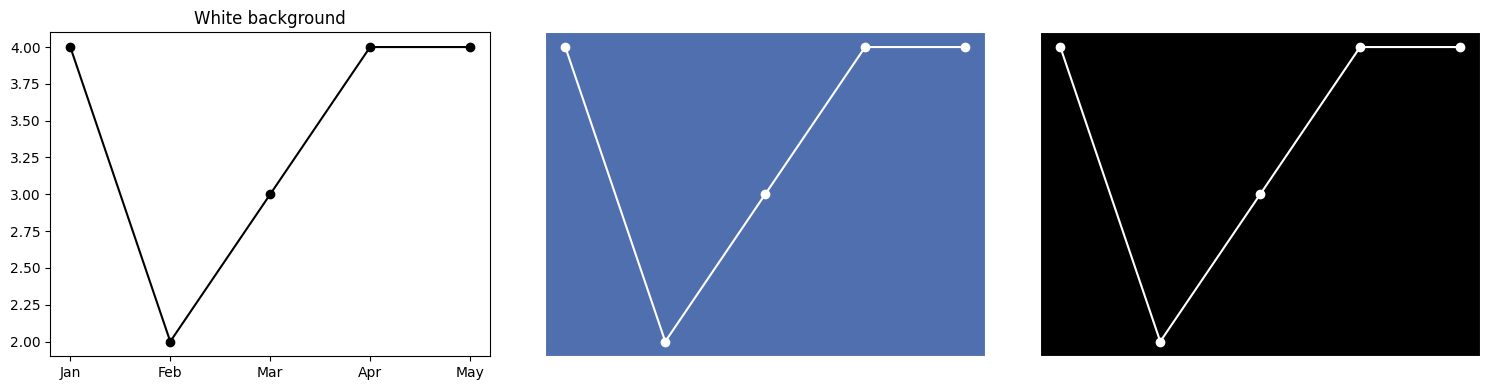

In [34]:
months = ["Jan", "Feb", "Mar", "Apr", "May"]
values = [4, 2, 3, 4, 4]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# White
axes[0].plot(months, values, marker='o', color='black')
axes[0].set_title("White background")
axes[0].set_facecolor("white")

# Blue
axes[1].plot(months, values, marker='o', color='white')
axes[1].set_title("Blue background", color='white')
axes[1].set_facecolor("#4f6fae")
axes[1].tick_params(colors='white')
for spine in axes[1].spines.values():
    spine.set_color('white')

# Black
axes[2].plot(months, values, marker='o', color='white')
axes[2].set_title("Black background", color='white')
axes[2].set_facecolor("black")
axes[2].tick_params(colors='white')
for spine in axes[2].spines.values():
    spine.set_color('white')

plt.tight_layout()
plt.show()